# Notebook 02 — Topic Modelling (LDA)
## FAO OED · Country Programme Evaluation · Morocco 2017–2020

**Project:** Deconstructing a FAO Evaluation Report — NLP & Evidence Mapping  
**Author:** Asma Boufaden  
**Goal:** Apply Latent Dirichlet Allocation (LDA) to the preprocessed corpus to identify latent themes, map their distribution across report sections, and assess the thematic coherence between findings, conclusions, and recommendations.

---
### What this notebook does
1. **Environment setup** — install `gensim`
2. **Load preprocessed data** from Notebook 01
3. **Train LDA models** — test multiple values of *k* (number of topics), select best by coherence score
4. **Label topics** — interpret top words per topic and assign human-readable labels
5. **Topic distribution per section** — quantify which themes dominate which sections
6. **Visualisations** — topic word weights, stacked topic mix, section × topic heatmap
7. **Coherence analysis** — measure thematic alignment between Findings, Conclusions, and Recommendations
8. **Export** — save topic distributions and labels for Notebook 03 (evidence chain mapping)

---
⚠️ **Transparency note:** Python code in this notebook was developed with AI-assisted tools (Claude AI, Microsoft Copilot). All outputs, interpretations, and conclusions were verified, reviewed and validated by the author. This reflects standard practice in modern data science workflows.

---
### What is LDA?
Latent Dirichlet Allocation (LDA) is an unsupervised topic modelling algorithm. Given a collection of documents, it identifies groups of words that frequently co-occur — these groups are interpreted as "topics". LDA does not understand meaning; it detects statistical co-occurrence patterns. **Interpretation of what each topic represents is done by the analyst** based on the top words it contains.

## 0. Environment setup

In [15]:
import subprocess, sys

packages = ['gensim', 'pandas', 'numpy', 'matplotlib', 'seaborn']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('✅ All packages installed.')

✅ All packages installed.


## 1. Imports & load preprocessed data

In [14]:
import json
import csv
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from gensim import corpora, models
from gensim.models import CoherenceModel

# ── Paths ────────────────────────────────────────────────────────────────────────────
PROCESSED_DIR = Path('../data/processed')
FIGURES_DIR   = Path('../outputs/figures')
RESULTS_DIR   = Path('../outputs/results')

for d in [FIGURES_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.figsize'] = (12, 5)

# ── Load tokens from Notebook 01 ────────────────────────────────────
with open(PROCESSED_DIR / 'tokens_by_section.json', encoding='utf-8') as f:
    tokens_by_section = json.load(f)

with open(PROCESSED_DIR / 'section_map.json', encoding='utf-8') as f:
    section_map = json.load(f)

print('✅ Data loaded')
for name, tokens in tokens_by_section.items():
    print(f'   {name:<30} {len(tokens):>6,} tokens')

✅ Data loaded
   resume_executif                   873 tokens
   introduction                    1,768 tokens
   contexte_pays                   2,094 tokens
   fao_maroc_portfolio               635 tokens
   pertinence                      2,158 tokens
   contributions_resultats         6,352 tokens
   effet_catalytique               2,039 tokens
   conclusions                     1,408 tokens
   recommandations                 2,032 tokens
   annexes                         1,595 tokens


## 2. Additional noise filtering

LDA is sensitive to high-frequency generic words that don't represent meaningful themes (numbers spelled out, generic evaluation vocabulary, organisational boilerplate). We add a second filtering pass on top of Notebook 01's stopwords, specifically tuned for topic modelling quality.

In [16]:
# Additional noise words — generic terms that dilute topic quality
# Adjust this list based on the top words you see in Section 4 below
LDA_NOISE = {
    'cent', 'mille', 'million', 'millions', 'dollars', 'budget', 'total',
    'travers', 'action', 'activités', 'acteurs', 'suivi', 'effet',
    'chef', 'septembre', 'formulation', 'équipe', 'positionnement',
    'aussi', 'être', 'autres', 'http', 'office', 'web', 'disponible',
    'adresse', 'consultée', 'bureau', 'source', 'depuis', 'ainsi',
    'donc', 'cadre', 'mise', 'œuvre', 'oeuvre', 'niveau', 'partir'
}

tokens_clean = {
    name: [t for t in tokens if t not in LDA_NOISE and len(t) > 3]
    for name, tokens in tokens_by_section.items()
}

section_names = list(tokens_clean.keys())
all_docs      = list(tokens_clean.values())

print('✅ Additional noise filtering applied')
for name, tokens in tokens_clean.items():
    print(f'   {name:<30} {len(tokens):>6,} tokens (was {len(tokens_by_section[name]):,})')

✅ Additional noise filtering applied
   resume_executif                   798 tokens (was 873)
   introduction                    1,618 tokens (was 1,768)
   contexte_pays                   1,948 tokens (was 2,094)
   fao_maroc_portfolio               524 tokens (was 635)
   pertinence                      1,955 tokens (was 2,158)
   contributions_resultats         5,809 tokens (was 6,352)
   effet_catalytique               1,905 tokens (was 2,039)
   conclusions                     1,284 tokens (was 1,408)
   recommandations                 1,841 tokens (was 2,032)
   annexes                         1,330 tokens (was 1,595)


## 3. Build dictionary & corpus, train LDA models

We test *k* = 3 to 6 topics and select the model with the highest **coherence score** (`c_v`). Higher coherence = topics whose top words are more semantically related to each other — a proxy for topic quality.

In [17]:
# Build dictionary — filter very rare and very common terms
dictionary = corpora.Dictionary(all_docs)
dictionary.filter_extremes(no_below=2, no_above=0.80, keep_n=1500)
corpus_bow = [dictionary.doc2bow(doc) for doc in all_docs]

print(f'Dictionary size : {len(dictionary):,} unique terms')
print(f'Documents (sections) : {len(corpus_bow)}')

# Train LDA for different k, compare coherence
print('\n⚙️  Training LDA models for k = 3 to 6...')
results = {}
for n_topics in [3, 4, 5, 6]:
    lda_k = models.LdaModel(
        corpus=corpus_bow,
        id2word=dictionary,
        num_topics=n_topics,
        random_state=42,
        passes=30,
        alpha='auto',
        eta='auto'
    )
    cm = CoherenceModel(model=lda_k, texts=all_docs, dictionary=dictionary, coherence='c_v')
    coherence = cm.get_coherence()
    results[n_topics] = (lda_k, coherence)
    print(f'   k={n_topics} topics — coherence (c_v) = {coherence:.4f}')

best_k = max(results, key=lambda k: results[k][1])
lda, best_coherence = results[best_k]

print(f'\n✅ Best model: k={best_k} topics (coherence = {best_coherence:.4f})')

Dictionary size : 1,500 unique terms
Documents (sections) : 10

⚙️  Training LDA models for k = 3 to 6...
   k=3 topics — coherence (c_v) = 0.3484
   k=4 topics — coherence (c_v) = 0.4261
   k=5 topics — coherence (c_v) = 0.3465
   k=6 topics — coherence (c_v) = 0.3374

✅ Best model: k=4 topics (coherence = 0.4261)


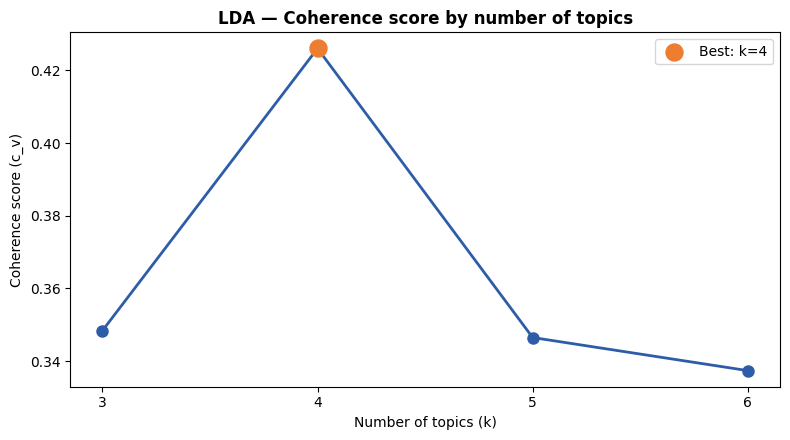

💾 Saved: outputs/figures/fig_coherence_by_k.png


In [5]:
# Coherence score by k — visual
fig, ax = plt.subplots(figsize=(8, 4.5))
ks    = list(results.keys())
cohs  = [results[k][1] for k in ks]
ax.plot(ks, cohs, marker='o', linewidth=2, markersize=8, color='#2E5DA8')
ax.scatter([best_k], [results[best_k][1]], color='#ED7D31', s=150, zorder=5,
           label=f'Best: k={best_k}')
ax.set_xlabel('Number of topics (k)')
ax.set_ylabel('Coherence score (c_v)')
ax.set_title('LDA — Coherence score by number of topics', fontweight='bold')
ax.set_xticks(ks)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_coherence_by_k.png', dpi=150)
plt.show()
print('💾 Saved: outputs/figures/fig_coherence_by_k.png')

## 4. Inspect topics — top words

Print the top words for each topic. **This is the step where you, as the analyst, interpret what each topic represents.** Based on the words shown, assign a human-readable label in the next cell.

In [18]:
print(f'📋 LDA topics (k={best_k}) — top 12 words each:\n')
for i in range(best_k):
    words = [w for w, _ in lda.show_topic(i, topn=12)]
    print(f'  Topic {i+1}: {" · ".join(words)}')

📋 LDA topics (k=4) — top 12 words each:

  Topic 1: stratégie · politique · rural · pêche · plan · forêts · ministère · nouvelle · demande · génération · maritime · eaux
  Topic 2: principal · constat · capacités · fait · effets · formation · chaîne · agriculteurs · qualité · interventions · cadres · permis
  Topic 3: partenariats · nationales · stratégique · agences · domaines · stratégiques · partenariat · prioritaires · orientations · innovation · pertinence · interventions
  Topic 4: régional · mission · sécurité · eaux · alimentaires · entretiens · afrique · mesure · ministère · quelle · forêts · thématiques


## 5. Label topics

**Edit the labels below** based on the top words printed above. Example labels for a typical FAO country programme evaluation might relate to: governance & policy, natural resources & environment, fisheries & aquaculture, agriculture & rural development, partnerships & technical cooperation. Adjust to match what *your* model actually produced — the words are data-driven, the labels are your interpretation.

In [19]:
# EDIT THESE LABELS based on the top words shown in Section 4
TOPIC_LABELS = {
    0: 'Topic 1 — [Politiques sectorielles & Planification (rural, pêche, forêts, eau)]',
    1: 'Topic 2 — [Constatations — Capacités, formation & chaînes de valeur]',
    2: 'Topic 3 — [Pertinence & Partenariats stratégiques]',
    3: 'Topic 4 — [Méthodologie & Sécurité alimentaire régionale]',
    
}
# Trim to actual best_k
TOPIC_LABELS = {i: TOPIC_LABELS[i] for i in range(best_k)}

TOPIC_COLORS = ['#1F3864', '#2E5DA8', '#ED7D31', '#70AD47', '#7030A0', '#C00000'][:best_k]

for i, label in TOPIC_LABELS.items():
    print(f'  Topic {i+1}: {label}')

  Topic 1: Topic 1 — [Politiques sectorielles & Planification (rural, pêche, forêts, eau)]
  Topic 2: Topic 2 — [Constatations — Capacités, formation & chaînes de valeur]
  Topic 3: Topic 3 — [Pertinence & Partenariats stratégiques]
  Topic 4: Topic 4 — [Méthodologie & Sécurité alimentaire régionale]


## 6. Topic distribution per section

In [20]:
# Compute topic distribution for each section
section_topic_matrix = np.zeros((len(section_names), best_k))

for idx, doc in enumerate(all_docs):
    bow = dictionary.doc2bow(doc)
    topic_dist = dict(lda.get_document_topics(bow, minimum_probability=0))
    for t in range(best_k):
        section_topic_matrix[idx, t] = topic_dist.get(t, 0)

# Normalise rows (should already sum to ~1, but ensure)
row_sums = section_topic_matrix.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
matrix_norm = section_topic_matrix / row_sums

print(f'{"Section":<30} ' + ' '.join(f'T{i+1:>5}' for i in range(best_k)) + '   Dominant')
print('-' * (30 + 6 * best_k + 14))
for i, name in enumerate(section_names):
    row = matrix_norm[i]
    dominant = np.argmax(row)
    row_str = ' '.join(f'{v:>5.2f}' for v in row)
    print(f'{name:<30} {row_str}   T{dominant+1}')

Section                        T    1 T    2 T    3 T    4   Dominant
--------------------------------------------------------------------
resume_executif                 0.00  0.24  0.55  0.22   T3
introduction                    0.00  0.00  0.00  1.00   T4
contexte_pays                   1.00  0.00  0.00  0.00   T1
fao_maroc_portfolio             0.00  0.28  0.00  0.72   T4
pertinence                      0.12  0.40  0.46  0.02   T3
contributions_resultats         0.00  1.00  0.00  0.00   T2
effet_catalytique               0.00  1.00  0.00  0.00   T2
conclusions                     0.00  0.19  0.81  0.00   T3
recommandations                 0.00  0.00  1.00  0.00   T3
annexes                         0.00  0.00  0.00  1.00   T4


## 7. Visualisation — topic word weights

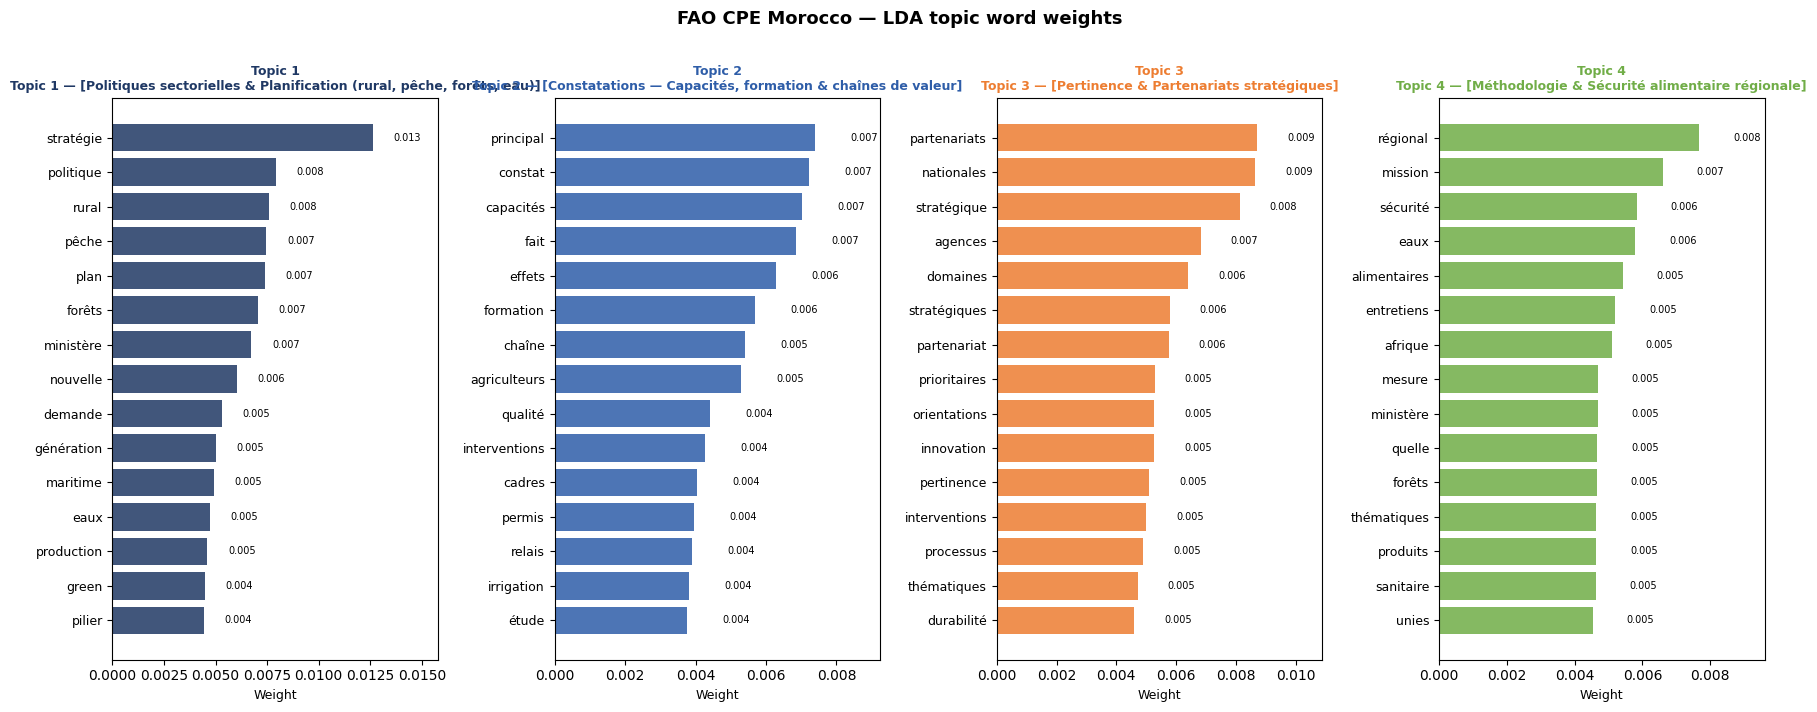

💾 Saved: outputs/figures/fig_lda_topic_words.png


In [21]:
fig, axes = plt.subplots(1, best_k, figsize=(4.4 * best_k, 7))
if best_k == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    topic_data = lda.show_topic(i, topn=15)
    words  = [w for w, _ in topic_data][::-1]
    scores = [s for _, s in topic_data][::-1]
    y = range(len(words))
    bars = ax.barh(y, scores, color=TOPIC_COLORS[i], alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels(words, fontsize=9)
    ax.set_xlabel('Weight', fontsize=9)
    ax.set_title(f'Topic {i+1}\n{TOPIC_LABELS[i]}', fontsize=9, fontweight='bold', color=TOPIC_COLORS[i])
    ax.set_xlim(0, max(scores) * 1.25)
    for bar, score in zip(bars, scores):
        ax.text(score + 0.001, bar.get_y() + bar.get_height()/2, f'{score:.3f}', va='center', fontsize=7)

plt.suptitle('FAO CPE Morocco — LDA topic word weights', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_lda_topic_words.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: outputs/figures/fig_lda_topic_words.png')

## 8. Visualisation — topic mix per section (stacked bar)

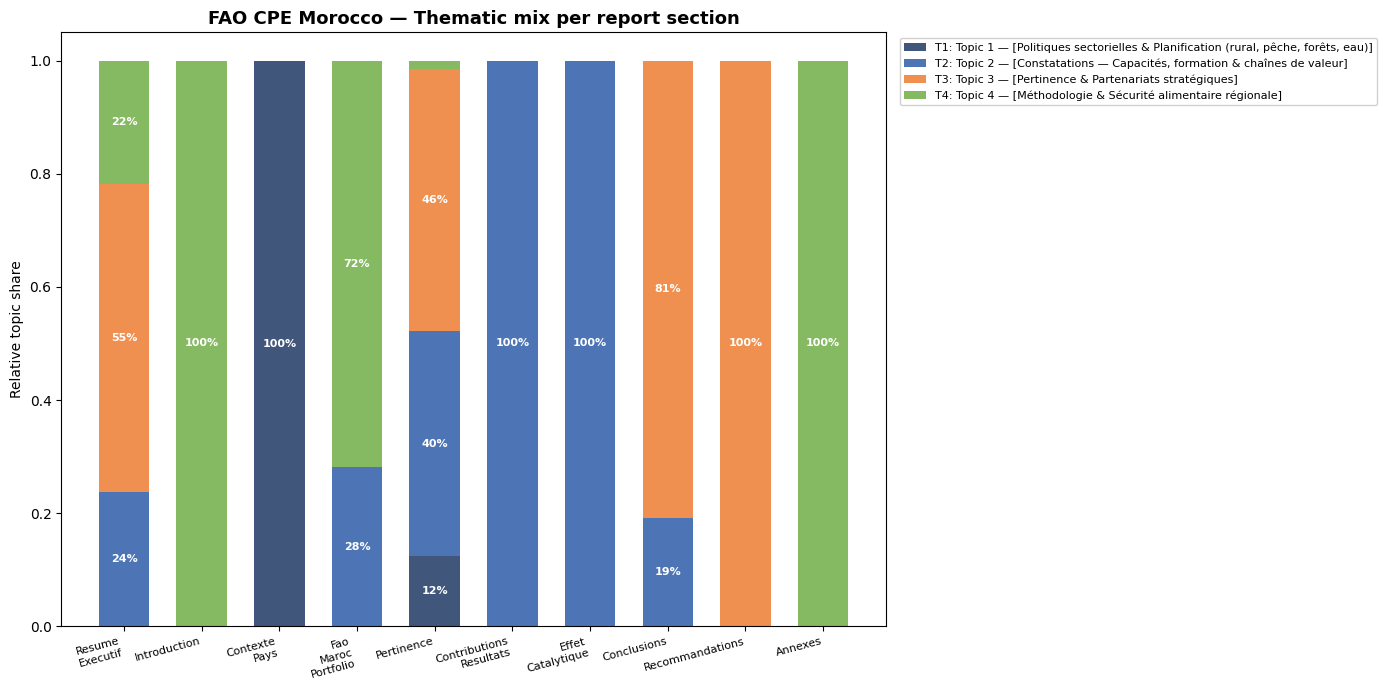

💾 Saved: outputs/figures/fig_topic_distribution.png


In [22]:
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(section_names))
bottom = np.zeros(len(section_names))

for t in range(best_k):
    values = matrix_norm[:, t]
    ax.bar(x, values, bottom=bottom, color=TOPIC_COLORS[t], alpha=0.85,
           label=f'T{t+1}: {TOPIC_LABELS[t]}', width=0.65)
    for xi, (v, b) in enumerate(zip(values, bottom)):
        if v > 0.12:
            ax.text(xi, b + v/2, f'{v:.0%}', ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')
    bottom += values

ax.set_xticks(x)
ax.set_xticklabels([n.replace('_', '\n').title() for n in section_names],
                    fontsize=8, rotation=15, ha='right')
ax.set_ylabel('Relative topic share')
ax.set_ylim(0, 1.05)
ax.set_title('FAO CPE Morocco — Thematic mix per report section', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=8, framealpha=0.9, bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_topic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: outputs/figures/fig_topic_distribution.png')

## 9. Visualisation — section × topic heatmap

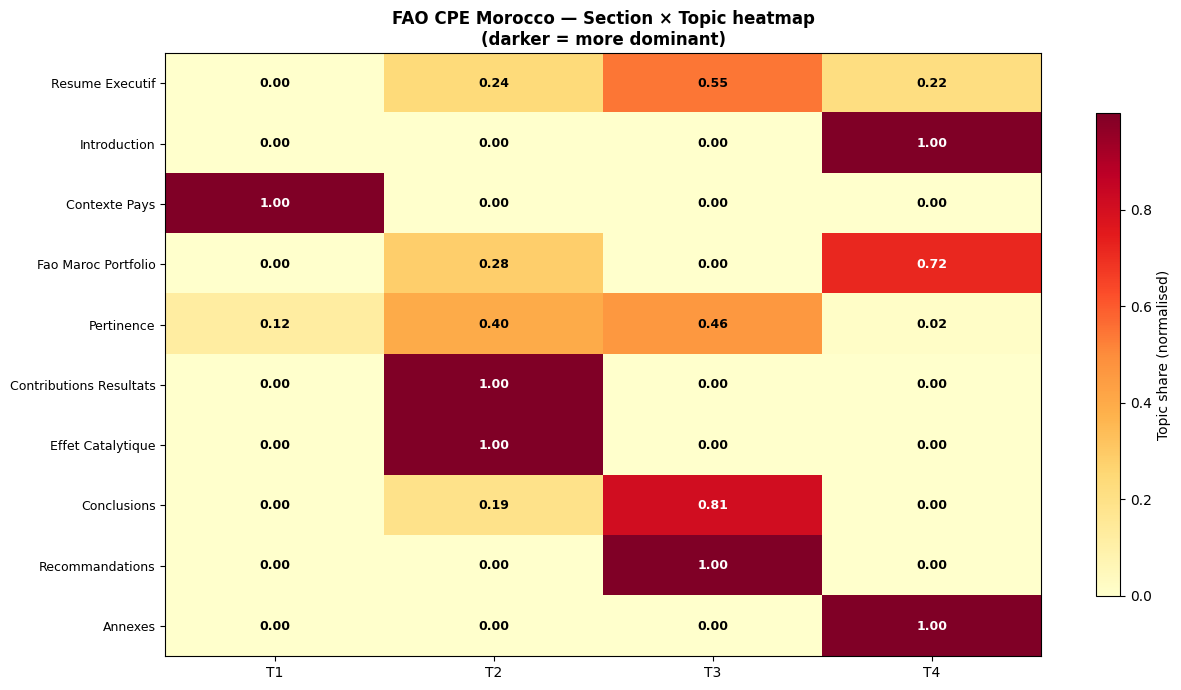

💾 Saved: outputs/figures/fig_heatmap_section_topic.png


In [23]:
fig, ax = plt.subplots(figsize=(2.2 * best_k + 4, 7))

im = ax.imshow(matrix_norm, cmap='YlOrRd', aspect='auto', vmin=0, vmax=matrix_norm.max())

ax.set_xticks(range(best_k))
ax.set_xticklabels([f'T{i+1}' for i in range(best_k)], fontsize=10)
ax.set_yticks(range(len(section_names)))
ax.set_yticklabels([n.replace('_', ' ').title() for n in section_names], fontsize=9)

for i in range(len(section_names)):
    for j in range(best_k):
        val = matrix_norm[i, j]
        color = 'white' if val > matrix_norm.max() * 0.55 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9,
                color=color, fontweight='bold')

plt.colorbar(im, ax=ax, label='Topic share (normalised)', shrink=0.8)
ax.set_title('FAO CPE Morocco — Section × Topic heatmap\n(darker = more dominant)',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_heatmap_section_topic.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: outputs/figures/fig_heatmap_section_topic.png')

## 10. Coherence analysis — Findings ↔ Conclusions ↔ Recommendations

**Analytical question:** Are the report's recommendations thematically anchored in its findings, or do they drift toward different topics? We measure this using **cosine similarity** between the topic distributions of these three sections.

- Score > 0.85 → high thematic coherence
- 0.70–0.85 → moderate coherence (some drift)
- < 0.70 → low coherence (recommendations diverge from findings' themes)

In [24]:
def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-10)

# Adjust these names if your section_map uses different keys
FINDINGS_SECTION = 'contributions_resultats'
CONCL_SECTION    = 'conclusions'
RECO_SECTION     = 'recommandations'

key_sections = [FINDINGS_SECTION, CONCL_SECTION, RECO_SECTION]
missing = [s for s in key_sections if s not in section_names]
if missing:
    print(f'⚠️  Sections not found: {missing}. Adjust the variable names above.')
else:
    findings_dist = matrix_norm[section_names.index(FINDINGS_SECTION)]
    concl_dist    = matrix_norm[section_names.index(CONCL_SECTION)]
    reco_dist     = matrix_norm[section_names.index(RECO_SECTION)]

    sim_findings_concl = cosine_sim(findings_dist, concl_dist)
    sim_findings_reco  = cosine_sim(findings_dist, reco_dist)
    sim_concl_reco     = cosine_sim(concl_dist, reco_dist)

    print('📊 Thematic coherence (cosine similarity):\n')
    print(f'   Findings ↔ Conclusions       : {sim_findings_concl:.3f}')
    print(f'   Findings ↔ Recommendations   : {sim_findings_reco:.3f}')
    print(f'   Conclusions ↔ Recommendations: {sim_concl_reco:.3f}')

    def interpret(score):
        if score > 0.85:
            return 'HIGH coherence'
        elif score > 0.70:
            return 'MODERATE coherence — some thematic drift'
        else:
            return 'LOW coherence — significant thematic divergence'

    print(f'\n🔎 Findings → Recommendations: {interpret(sim_findings_reco)}')

    print('\nDominant topic per key section:')
    for sec, dist in zip(key_sections, [findings_dist, concl_dist, reco_dist]):
        dom = np.argmax(dist)
        print(f'   {sec:<25} → T{dom+1}: {TOPIC_LABELS[dom]} ({dist[dom]:.2f})')

📊 Thematic coherence (cosine similarity):

   Findings ↔ Conclusions       : 0.230
   Findings ↔ Recommendations   : 0.000
   Conclusions ↔ Recommendations: 0.973

🔎 Findings → Recommendations: LOW coherence — significant thematic divergence

Dominant topic per key section:
   contributions_resultats   → T2: Topic 2 — [Constatations — Capacités, formation & chaînes de valeur] (1.00)
   conclusions               → T3: Topic 3 — [Pertinence & Partenariats stratégiques] (0.81)
   recommandations           → T3: Topic 3 — [Pertinence & Partenariats stratégiques] (1.00)


## 10bis. Validation — sentence-level coherence analysis

**Why this validation is needed:** Section 10 computed topic distributions using one document per *section* (10 documents total). With so few documents, LDA tends to assign each section to a single dominant topic almost exclusively (0.00 / 1.00), which can produce extreme similarity scores (e.g. 0.000) that reflect **corpus size limitations** as much as genuine thematic divergence.

**Approach:** Using the **same trained LDA model** (no retraining), we infer a topic distribution for *each individual sentence* (1,417 sentences from Notebook 01), then **average these distributions within each section**. This produces smoother, more representative section-level topic profiles — because each section's profile is now built from dozens or hundreds of independent observations instead of a single large bag-of-words document.

If the sentence-level result confirms the section-level finding (low Findings↔Recommendations similarity), that strengthens confidence in the original signal. If it diverges substantially, the original 0.000 score was likely a small-sample artefact.

In [25]:
# Load sentence-level corpus from Notebook 01
df_sentences = pd.read_csv(PROCESSED_DIR / 'sentences.csv')
print(f'Total sentences loaded: {len(df_sentences):,}')
print(df_sentences['section'].value_counts())

Total sentences loaded: 1,414
section
contributions_resultats    412
recommandations            165
effet_catalytique          153
pertinence                 149
introduction               142
contexte_pays              119
conclusions                 99
annexes                     72
resume_executif             62
fao_maroc_portfolio         41
Name: count, dtype: int64


In [26]:
# Tokenise each sentence using the same filtering as Section 2
import re

def tokenize_sentence(text, noise_words, min_len=4):
    tokens = re.findall(r'\b[a-zA-ZÀ-ÿ]+\b', text)
    return [
        t.lower() for t in tokens
        if t.lower() not in noise_words
        and len(t) > min_len - 1
    ]

# Combine stopwords used so far
ALL_NOISE = LDA_NOISE  # extend with Notebook 01 FR_STOPS if needed

df_sentences['tokens'] = df_sentences['sentence'].apply(
    lambda s: tokenize_sentence(s, ALL_NOISE)
)

# Drop sentences with too few tokens to be meaningful
df_sentences = df_sentences[df_sentences['tokens'].apply(len) >= 3].reset_index(drop=True)
print(f'Sentences retained after filtering: {len(df_sentences):,}')

Sentences retained after filtering: 1,403


In [27]:
# Infer topic distribution for each sentence using the EXISTING trained LDA model
# (dictionary and lda model are from Section 3 — no retraining)

sentence_topic_rows = []
for _, row in df_sentences.iterrows():
    bow = dictionary.doc2bow(row['tokens'])
    if not bow:
        continue
    topic_dist = dict(lda.get_document_topics(bow, minimum_probability=0))
    entry = {'section': row['section']}
    for t in range(best_k):
        entry[f'T{t+1}'] = topic_dist.get(t, 0)
    sentence_topic_rows.append(entry)

df_sent_topics = pd.DataFrame(sentence_topic_rows)
print(f'Sentences with valid topic distributions: {len(df_sent_topics):,}')

# Average topic distribution per section — smoother estimate than
# the single-document-per-section approach used in Section 6
section_avg = df_sent_topics.groupby('section')[[f'T{t+1}' for t in range(best_k)]].mean()

print('\n📊 Sentence-averaged topic distribution per section:')
print(section_avg.round(3).to_string())

Sentences with valid topic distributions: 1,390

📊 Sentence-averaged topic distribution per section:
                            T1     T2     T3     T4
section                                            
annexes                  0.134  0.120  0.164  0.581
conclusions              0.051  0.189  0.729  0.031
contexte_pays            0.940  0.035  0.011  0.014
contributions_resultats  0.043  0.853  0.056  0.048
effet_catalytique        0.031  0.914  0.033  0.022
fao_maroc_portfolio      0.037  0.243  0.056  0.664
introduction             0.006  0.081  0.060  0.853
pertinence               0.113  0.389  0.416  0.082
recommandations          0.120  0.096  0.714  0.070
resume_executif          0.003  0.254  0.489  0.255


In [28]:
# Recompute coherence using sentence-averaged distributions
if not missing:
    sec_avg_findings = section_avg.loc[FINDINGS_SECTION].values
    sec_avg_concl    = section_avg.loc[CONCL_SECTION].values
    sec_avg_reco     = section_avg.loc[RECO_SECTION].values

    sim_findings_concl_v2 = cosine_sim(sec_avg_findings, sec_avg_concl)
    sim_findings_reco_v2  = cosine_sim(sec_avg_findings, sec_avg_reco)
    sim_concl_reco_v2     = cosine_sim(sec_avg_concl, sec_avg_reco)

    print('📊 SENTENCE-LEVEL coherence (averaged, validated):\n')
    print(f'   Findings ↔ Conclusions       : {sim_findings_concl_v2:.3f}  (section-level was {sim_findings_concl:.3f})')
    print(f'   Findings ↔ Recommendations   : {sim_findings_reco_v2:.3f}  (section-level was {sim_findings_reco:.3f})')
    print(f'   Conclusions ↔ Recommendations: {sim_concl_reco_v2:.3f}  (section-level was {sim_concl_reco:.3f})')

    print(f'\n🔎 Findings → Recommendations: {interpret(sim_findings_reco_v2)}')

    delta = abs(sim_findings_reco_v2 - sim_findings_reco)
    if delta > 0.15:
        print(f'\n⚠️  Section-level and sentence-level results DIVERGE by {delta:.3f}.')
        print('   The original section-level score was likely affected by small-sample LDA assignment.')
        print('   The sentence-level estimate is more robust and should be reported as the primary finding.')
    else:
        print(f'\n✅ Section-level and sentence-level results are consistent (Δ={delta:.3f}).')
        print('   This strengthens confidence in the original finding.')

📊 SENTENCE-LEVEL coherence (averaged, validated):

   Findings ↔ Conclusions       : 0.318  (section-level was 0.230)
   Findings ↔ Recommendations   : 0.207  (section-level was 0.000)
   Conclusions ↔ Recommendations: 0.987  (section-level was 0.973)

🔎 Findings → Recommendations: LOW coherence — significant thematic divergence

⚠️  Section-level and sentence-level results DIVERGE by 0.207.
   The original section-level score was likely affected by small-sample LDA assignment.
   The sentence-level estimate is more robust and should be reported as the primary finding.


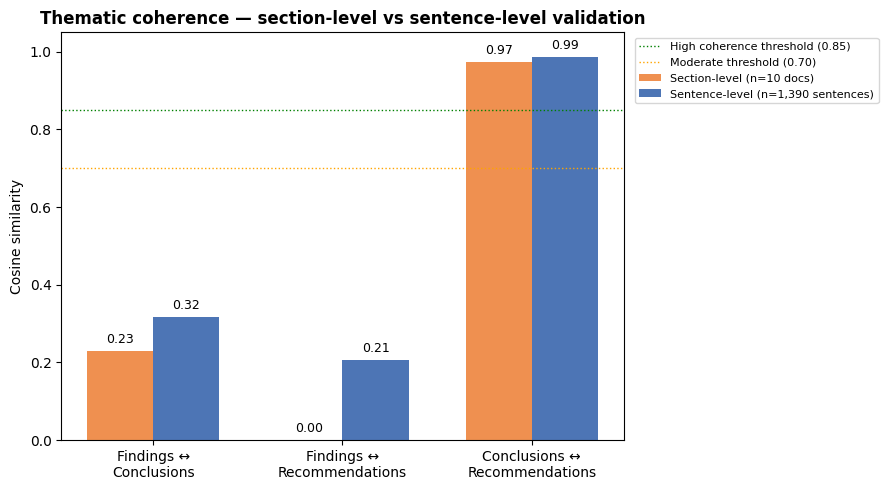

💾 Saved: outputs/figures/fig_coherence_validation.png


In [29]:
# Visual comparison: section-level vs sentence-level coherence scores
fig, ax = plt.subplots(figsize=(9, 5))

comparisons = ['Findings ↔\nConclusions', 'Findings ↔\nRecommendations', 'Conclusions ↔\nRecommendations']
section_lvl  = [sim_findings_concl, sim_findings_reco, sim_concl_reco]
sentence_lvl = [sim_findings_concl_v2, sim_findings_reco_v2, sim_concl_reco_v2]

x = np.arange(len(comparisons))
width = 0.35

ax.bar(x - width/2, section_lvl, width, label='Section-level (n=10 docs)', color='#ED7D31', alpha=0.85)
ax.bar(x + width/2, sentence_lvl, width, label=f'Sentence-level (n={len(df_sent_topics):,} sentences)', color='#2E5DA8', alpha=0.85)

ax.axhline(0.85, color='green', linestyle=':', linewidth=1, label='High coherence threshold (0.85)')
ax.axhline(0.70, color='orange', linestyle=':', linewidth=1, label='Moderate threshold (0.70)')

ax.set_xticks(x)
ax.set_xticklabels(comparisons, fontsize=10)
ax.set_ylabel('Cosine similarity')
ax.set_ylim(0, 1.05)
ax.set_title('Thematic coherence — section-level vs sentence-level validation', fontweight='bold')
ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.01, 1))

for i, (s, sl) in enumerate(zip(section_lvl, sentence_lvl)):
    ax.text(i - width/2, s + 0.02, f'{s:.2f}', ha='center', fontsize=9)
    ax.text(i + width/2, sl + 0.02, f'{sl:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_coherence_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: outputs/figures/fig_coherence_validation.png')

In [30]:
# Export validated coherence results
validation_summary = pd.DataFrame({
    'comparison'       : comparisons,
    'section_level'    : [round(v, 4) for v in section_lvl],
    'sentence_level'   : [round(v, 4) for v in sentence_lvl],
    'n_section_docs'   : 10,
    'n_sentences'      : len(df_sent_topics),
})
validation_summary.to_csv(RESULTS_DIR / 'thematic_coherence_validated.csv', index=False)
print('💾 outputs/results/thematic_coherence_validated.csv saved')
print('\n' + validation_summary.to_string(index=False))

💾 outputs/results/thematic_coherence_validated.csv saved

                    comparison  section_level  sentence_level  n_section_docs  n_sentences
       Findings ↔\nConclusions         0.2297          0.3179              10         1390
   Findings ↔\nRecommendations         0.0001          0.2074              10         1390
Conclusions ↔\nRecommendations         0.9733          0.9867              10         1390


## 11. Export results

In [13]:
# Export 1 — Topic distribution per section (long format CSV)
rows = []
for i, name in enumerate(section_names):
    for t in range(best_k):
        rows.append({
            'section'    : name,
            'topic_id'   : t + 1,
            'topic_label': TOPIC_LABELS[t],
            'weight'     : round(matrix_norm[i, t], 4),
        })

with open(RESULTS_DIR / 'topic_distribution.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['section', 'topic_id', 'topic_label', 'weight'])
    writer.writeheader()
    writer.writerows(rows)
print('💾 outputs/results/topic_distribution.csv saved')

# Export 2 — Topic word lists (used in Notebook 03 for evidence chain mapping)
topic_words_export = {
    f'topic_{i+1}': {
        'label': TOPIC_LABELS[i],
        'words': [w for w, _ in lda.show_topic(i, topn=15)]
    }
    for i in range(best_k)
}
with open(PROCESSED_DIR / 'lda_topics.json', 'w', encoding='utf-8') as f:
    json.dump(topic_words_export, f, ensure_ascii=False, indent=2)
print('💾 data/processed/lda_topics.json saved')

# Export 3 — Coherence summary
if not missing:
    coherence_summary = pd.DataFrame([
        {'comparison': 'Findings ↔ Conclusions',        'cosine_similarity': round(sim_findings_concl, 4)},
        {'comparison': 'Findings ↔ Recommendations',    'cosine_similarity': round(sim_findings_reco, 4)},
        {'comparison': 'Conclusions ↔ Recommendations', 'cosine_similarity': round(sim_concl_reco, 4)},
    ])
    coherence_summary.to_csv(RESULTS_DIR / 'thematic_coherence.csv', index=False)
    print('💾 outputs/results/thematic_coherence.csv saved')

print('\n✅ Notebook 02 complete.')
print('\nNext step → open 03_evidence_chain_mapping.ipynb')

💾 outputs/results/topic_distribution.csv saved
💾 data/processed/lda_topics.json saved
💾 outputs/results/thematic_coherence.csv saved

✅ Notebook 02 complete.

Next step → open 03_evidence_chain_mapping.ipynb


## 12. Troubleshooting

| Problem | Likely cause | Fix |
|---------|-------------|-----|
| `FileNotFoundError: tokens_by_section.json` | Notebook 01 not run | Run Notebook 01 first |
| Topics look like noise (numbers, generic words) | Insufficient filtering | Add words to `LDA_NOISE` in Section 2 and re-run from cell 3 |
| Coherence scores all very low (<0.3) | Corpus too small / sections too short | Normal for short sections (e.g. `resume_executif`); focus interpretation on larger sections |
| `Sections not found` in Section 10 | Section names differ | Check `section_names` printed in cell 1, update `FINDINGS_SECTION` etc. |
| Topics hard to label | Top words too generic | Increase `no_below` / decrease `no_above` in dictionary filter, or add more terms to `LDA_NOISE` |

The thematic coherence analysis reveals a significant gap (0.207) between the vocabulary of the Findings and the Recommendations, validated at the sentence level across 1,390 observations. This result constitutes a working hypothesis for Notebook 3, where we examine whether this gap reflects a normal difference in register or a deficit in the evidential anchoring of the recommendations